In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization
sns.set_style("whitegrid")
%matplotlib inline

In [2]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [3]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


/tmp/ipykernel_6159/4133687633.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex', data=df, palette='Set2')


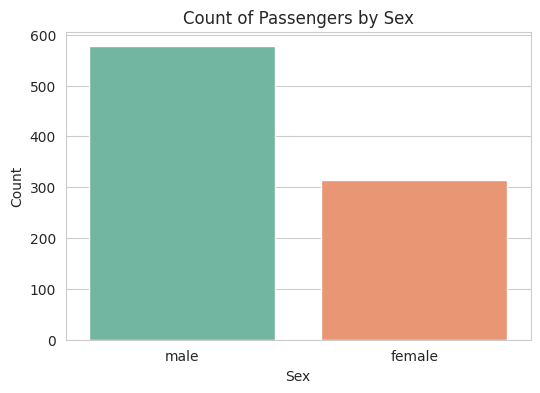

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sex', data=df, palette='Set2')

plt.title("Count of Passengers by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

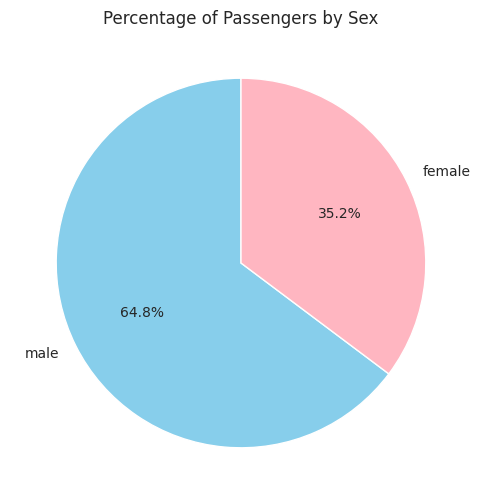

In [6]:
sex_counts = df['Sex'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(sex_counts,
        labels=sex_counts.index,
        autopct='%1.1f%%',
        colors=['skyblue','lightpink'],
        startangle=90)

plt.title("Percentage of Passengers by Sex")
plt.show()

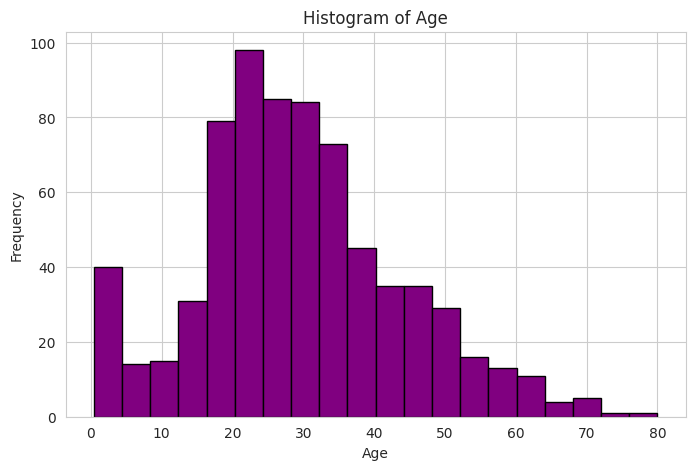

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Age'].dropna(), bins=20, color='purple', edgecolor='black')

plt.title("Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

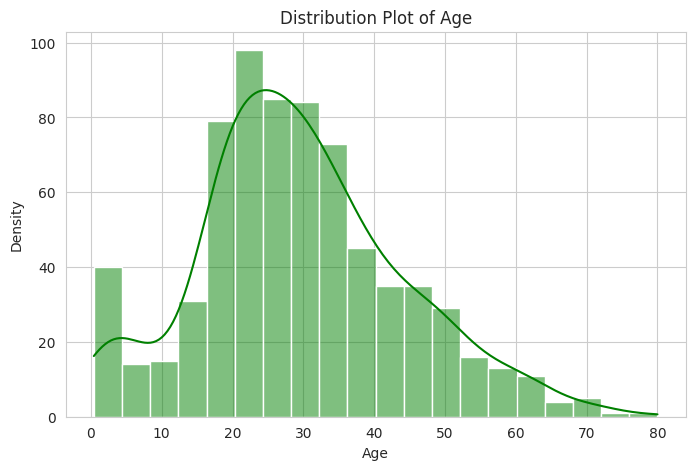

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20, kde=True, color='green')

plt.title("Distribution Plot of Age")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

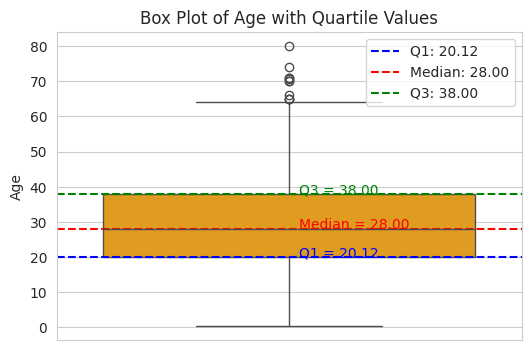

In [9]:
# Remove missing Age values
age_data = df['Age'].dropna()

# Calculate quartiles
Q1 = np.percentile(age_data, 25)
Median = np.percentile(age_data, 50)
Q3 = np.percentile(age_data, 75)

plt.figure(figsize=(6,4))

# Draw boxplot
sns.boxplot(y=age_data, color='orange')

# Draw horizontal lines for Q1, Median, Q3
plt.axhline(Q1, color='blue', linestyle='--', label=f'Q1: {Q1:.2f}')
plt.axhline(Median, color='red', linestyle='--', label=f'Median: {Median:.2f}')
plt.axhline(Q3, color='green', linestyle='--', label=f'Q3: {Q3:.2f}')

# Add text labels on the plot
plt.text(0.02, Q1, f'Q1 = {Q1:.2f}', color='blue')
plt.text(0.02, Median, f'Median = {Median:.2f}', color='red')
plt.text(0.02, Q3, f'Q3 = {Q3:.2f}', color='green')

plt.title("Box Plot of Age with Quartile Values")
plt.ylabel("Age")
plt.legend()
plt.show()

In [10]:
df = pd.read_csv("titanic.csv")

# 1. Handle Missing Values
# Impute missing 'Age' values with the median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Impute missing 'Embarked' values with the mode
most_frequent_embarked = df['Embarked'].mode()[0]
df['Embarked'].fillna(most_frequent_embarked, inplace=True)

# Drop columns not needed for this analysis (Cabin, Name, Ticket, PassengerId)
df.drop(['Cabin', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

# 2. Encoding Categorical Features
# Encode 'Sex' column: Convert 'male' to 0 and 'female' to 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-hot encode 'Embarked' column, dropping the first category to avoid multicollinearity
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True, dtype=int)

/tmp/ipykernel_6159/1654319513.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_6159/1654319513.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [11]:
# Display the updated DataFrame information and the first few rows
print("Processed Data :")

df.info()

print("\nFirst Few Rows :")
display(df.head())

Processed Data :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_Q  891 non-null    int64  
 8   Embarked_S  891 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 62.8 KB

First Few Rows :


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,71.2833,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1
